# Fagprojekt temp

## Setup

In [1]:
from pathlib import Path
import os

import numpy as np
import vedo
from vedo import settings
from PIL import Image
from skimage.measure import label, regionprops
import torch
from transformers import AutoImageProcessor, AutoModel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from scipy import ndimage
from sklearn.metrics.pairwise import cosine_similarity
import math

settings.default_backend = "vtk"

In [2]:
# Settings up DinoV2

model_name = "facebook/dinov2-base"
device = "cpu"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

model.eval()

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

C:\Users\samue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\samue\.cache\huggingface\hub\models--facebook--dinov2-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

## Main Functions

In [3]:
def get_tokens(file_name):
    image = Image.open(file_name).convert('RGB')

    inputs = processor(image, return_tensors='pt', do_resize=False, do_center_crop=False)
    outputs = model(**inputs)

    tokens = outputs.last_hidden_state[:, 1:].detach().numpy()

    return tokens[0]

In [4]:
def segment_and_render(file_name, out_dir, base="test", img_size=(980, 980)):
    os.makedirs(out_dir, exist_ok=True)

    # Load volume
    data = vedo.load(file_name).tonumpy()

    # Threshold + mask
    mask = data > np.percentile(data, 97.5)

    # Cleanup
    structure = np.ones((3, 3, 3))
    mask = ndimage.binary_opening(mask, structure=structure)
    mask = ndimage.binary_closing(mask, structure=structure)
    mask = ndimage.binary_fill_holes(mask)

    # Largest connected component
    labeled, num = ndimage.label(mask)
    if num == 0:
        raise ValueError("No connected components found.")

    sizes = ndimage.sum(mask, labeled, index=np.arange(1, num + 1))
    largest = np.argmax(sizes) + 1
    mask = labeled == largest

    # Apply mask
    clean_data = np.zeros_like(data)
    clean_data[mask] = data[mask]
    clean_vol = vedo.Volume(clean_data)

    # Camera setup
    xmin, xmax, ymin, ymax, zmin, zmax = clean_vol.bounds()
    c = np.array([(xmin + xmax)/2, (ymin + ymax)/2, (zmin + zmax)/2])
    d = np.linalg.norm([xmax-xmin, ymax-ymin, zmax-zmin]) * 1.5

    views = [
        ("+X",  c + [ d, 0, 0],  [0, 0, 1]),
        ("-X",  c + [-d, 0, 0],  [0, 0, 1]),
        ("+Y",  c + [0,  d, 0],  [0, 0, 1]),
        ("-Y",  c + [0, -d, 0],  [0, 0, 1]),
        ("+Z",  c + [0, 0,  d],  [0, 1, 0]),
        ("-Z",  c + [0, 0, -d],  [0, 1, 0]),
    ]

    # Render and save
    plt = vedo.Plotter(size=img_size, offscreen=True, bg="white")

    for i, (name, pos, vup) in enumerate(views, 1):
        plt.clear()
        plt.show(clean_vol, resetcam=True, zoom=1.2)

        cam = plt.camera
        cam.SetFocalPoint(*c)
        cam.SetPosition(*pos)
        cam.SetViewUp(*vup)

        plt.renderer.ResetCameraClippingRange()
        plt.screenshot(os.path.join(out_dir, f"{base}_{i}_{name}.png"))

    plt.close()

In [5]:
def get_pixel_feature_from_tokens(filename, tokens, x, y, patch_size=14):
    """
    Args:
        tokens: torch.Tensor of shape [N, D] or [1, N, D]
        filename: path to original image
        x, y: pixel coordinates in original image
        patch_size: DINOv2 patch size (default 14)

    Returns:
        feature vector (torch.Tensor) for the corresponding patch
    """

    # Handle batch dimension
    if tokens.ndim == 3:
        tokens = tokens[0]  # [N, D]

    # Load image to get original size
    image = Image.open(filename).convert("RGB")
    orig_w, orig_h = image.size

    # Infer grid size from tokens
    num_patches = tokens.shape[0]
    grid_w = int(num_patches ** 0.5)
    grid_h = num_patches // grid_w

    # Compute processed image size (what model saw)
    proc_w = grid_w * patch_size
    proc_h = grid_h * patch_size

    # Map original pixel → processed pixel
    scale_x = proc_w / orig_w
    scale_y = proc_h / orig_h

    px = int(x * scale_x)
    py = int(y * scale_y)

    # Clamp
    px = min(px, proc_w - 1)
    py = min(py, proc_h - 1)

    # Pixel → patch index
    col = px // patch_size
    row = py // patch_size
    index = row * grid_w + col

    return tokens[index]

In [6]:
def plot_patch_similarity(head_vector, tokens):
    sims = cosine_similarity([head_vector], tokens)
    sim_map = sims.reshape(70,70)
    plt.imshow(sim_map, cmap="jet")
    plt.colorbar()
    plt.title("Patch similarity map")
    plt.axis("off")
    plt.show()

In [7]:
def overlay_similarity(image, sims, grid_h=70, grid_w=70, alpha=0.5):
    """
    image: PIL image
    sims: flat similarity array of length grid_h*grid_w, or [grid_h, grid_w]
    """
    if sims.ndim == 1:
        sim_map = sims.reshape(grid_h, grid_w)
    else:
        sim_map = sims

    # normalize to [0, 1] for display
    lo, hi = sim_map.min(), sim_map.max()
    sim_map_norm = (sim_map - lo) / (hi - lo + 1e-8)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.imshow(
        sim_map_norm,
        cmap="jet",
        alpha=alpha,
        interpolation="nearest",
        extent=(0, image.size[0], image.size[1], 0),
    )
    plt.colorbar(label="Cosine similarity")
    plt.axis("off")
    plt.title("Similarity overlay")
    plt.show()

In [8]:
def get_head_position(sims, image_size=(980, 980), grid_size=(70, 70), patch_size=14, threshold=0.8):
    # This looks at the top 20% percent of similarities and calculates mean, 
    # not necessarily local, only works when one region is identified at the head
    sims = np.asarray(sims).squeeze()
    grid_h, grid_w = grid_size
    sim_map = sims.reshape(grid_h, grid_w)

    mask = sim_map >= threshold * sim_map.max()
    weights = sim_map * mask

    rows, cols = np.indices((grid_h, grid_w))

    row = (rows * weights).sum() / weights.sum()
    col = (cols * weights).sum() / weights.sum()

    x = (col + 0.5) * patch_size
    y = (row + 0.5) * patch_size

    W, H = image_size
    x = np.clip(x, 0, W - 1)
    y = np.clip(y, 0, H - 1)

    return x, y

In [9]:
def get_head_position_local(sims, patch_size=14, grid_size=(70, 70), window=11):
    sims = np.asarray(sims).squeeze()
    grid_h, grid_w = grid_size
    sim_map = sims.reshape(grid_h, grid_w)

    r0, c0 = np.unravel_index(np.argmax(sim_map), sim_map.shape)

    half = window // 2
    r1 = max(0, r0 - half)
    r2 = min(grid_h, r0 + half + 1)
    c1 = max(0, c0 - half)
    c2 = min(grid_w, c0 + half + 1)

    local = sim_map[r1:r2, c1:c2]
    weights = local - local.min()

    if weights.sum() == 0:
        row, col = r0, c0
    else:
        rows, cols = np.indices(local.shape)
        row = r1 + (rows * weights).sum() / weights.sum()
        col = c1 + (cols * weights).sum() / weights.sum()

    x = (col + 0.5) * patch_size
    y = (row + 0.5) * patch_size

    return x, y

In [10]:
def plot_head(image_path, x, y):
    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(6, 6))
    plt.imshow(image)

    # plot point
    plt.scatter(x, y, c="red", s=20)

    # optional: small circle for visibility
    circle = plt.Circle((x, y), 10, color="red", fill=False, linewidth=2)
    plt.gca().add_patch(circle)

    plt.axis("off")
    plt.title(f"Head position: ({int(x)}, {int(y)})")
    plt.show()

In [11]:
def get_xy_angles(base, head_vector, root_dir):
    """
    Find head (x, y) positions for all 6 angle images in:
        root_dir/base/

    Example:
        base = "gras_1_001"
        root_dir = r"data\new_photos\segmented\GH"

    Looks inside:
        data\new_photos\segmented\GH\gras_1_001

    Returns:
        dict like {
            "+X": {"file": "...", "x": ..., "y": ...},
            "-X": {"file": "...", "x": ..., "y": ...},
            "+Y": {"file": "...", "x": ..., "y": ...},
            "-Y": {"file": "...", "x": ..., "y": ...},
            "+Z": {"file": "...", "x": ..., "y": ...},
            "-Z": {"file": "...", "x": ..., "y": ...},
        }
    """
    folder = os.path.join(root_dir, base)

    angle_map = {
        "_1_+X.png": "+X",
        "_2_-X.png": "-X",
        "_3_+Y.png": "+Y",
        "_4_-Y.png": "-Y",
        "_5_+Z.png": "+Z",
        "_6_-Z.png": "-Z",
    }

    results = {}

    for filename in os.listdir(folder):
        filepath = os.path.join(folder, filename)

        if not os.path.isfile(filepath):
            continue

        angle = None
        for suffix, name in angle_map.items():
            if filename.endswith(suffix):
                angle = name
                break

        if angle is None:
            continue

        tokens = get_tokens(filepath)
        sims = cosine_similarity([head_vector], tokens)
        x, y = get_head_position_local(sims)

        results[angle] = {
            "file": filepath,
            "x": x,
            "y": y,
        }

    return results

In [12]:
def plot_xy_angles(xy_angles):
    """
    Plot all 6 angle images with the detected head position marked.

    Args:
        xy_angles: output from get_xy_angles(), e.g.
            {
                "+X": {"file": "...", "x": ..., "y": ...},
                "-X": {"file": "...", "x": ..., "y": ...},
                "+Y": {"file": "...", "x": ..., "y": ...},
                "-Y": {"file": "...", "x": ..., "y": ...},
                "+Z": {"file": "...", "x": ..., "y": ...},
                "-Z": {"file": "...", "x": ..., "y": ...},
            }
    """
    view_order = ["+X", "-X", "+Y", "-Y", "+Z", "-Z"]
    views = [v for v in view_order if v in xy_angles]

    n = len(views)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
    axes = axes.flatten()

    for ax, view in zip(axes, views):
        info = xy_angles[view]
        image = Image.open(info["file"]).convert("RGB")
        x, y = info["x"], info["y"]

        ax.imshow(image)
        ax.scatter(x, y, c="red", s=100)
        ax.add_patch(plt.Circle((x, y), 10, color="red", fill=False, linewidth=2))
        ax.set_title(view)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [18]:
file_name = "data/original_photos/GH/gras_1_001.tif"
out_dir   = "data/new_photos/segmented/GH/gras_1_001"
base      = "gras_1_001"

segment_and_render(file_name, out_dir, base)

In [24]:
file_name_seg = r"data\new_photos\segmented\GH\gras_1_000\gras_1_000_1_+X.png"
tokens1 = get_tokens(file_name_seg)
head_vector = get_pixel_feature_from_tokens(file_name_seg,tokens,596,263)

In [25]:
file_name_seg2 = r"data\new_photos\segmented\GH\gras_1_001\gras_1_001_3_+Y.png"
tokens2 = get_tokens(file_name_seg2)

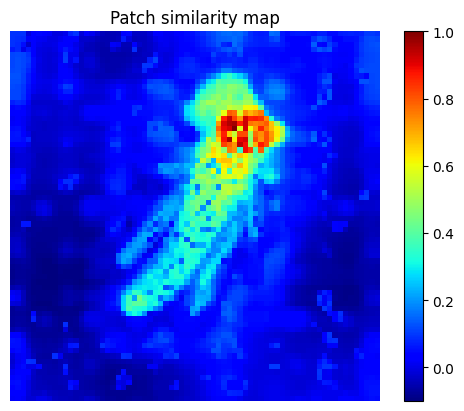

In [26]:
plot_patch_similarity(head_vector, tokens1)

In [27]:
sims = cosine_similarity([head_vector], tokens1)[0]
image = Image.open(file_name_seg2).convert('RGB')

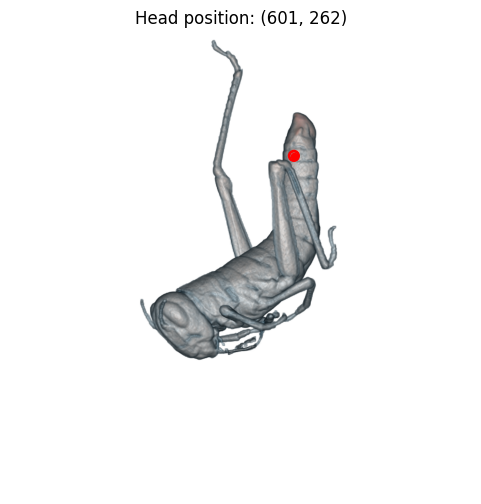

In [28]:
x, y = get_head_position_local(sims)
plot_head(file_name_seg2,x,y)

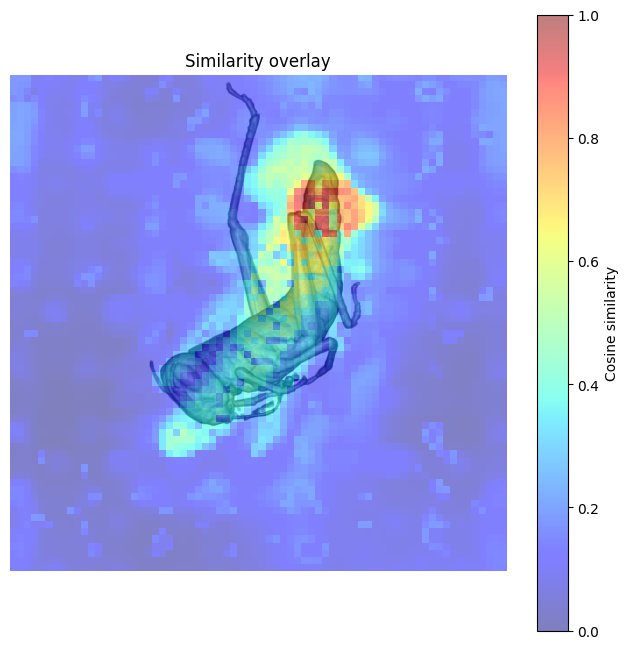

In [29]:
overlay_similarity(image,sims)

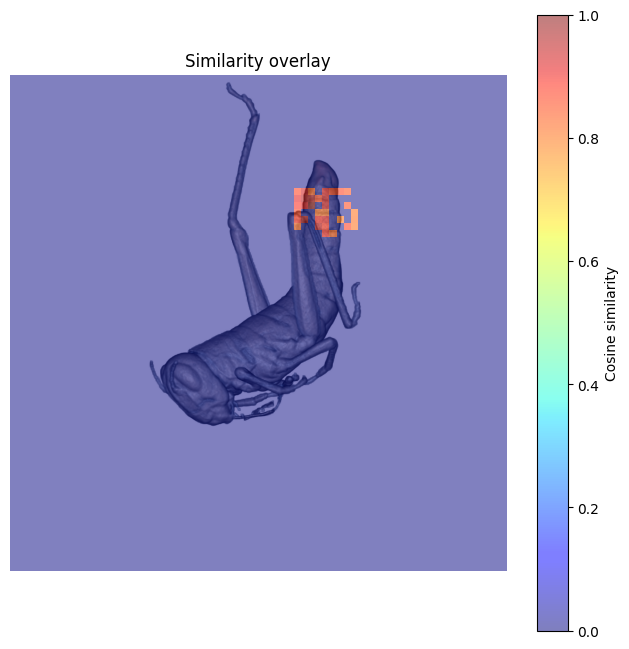

In [30]:
sims = np.asarray(sims).squeeze()
grid_h, grid_w = 70,70
sim_map = sims.reshape(grid_h, grid_w)

mask = sim_map >= 0.8 * sim_map.max()
weights = sim_map * mask

overlay_similarity(image,weights)

In [31]:
xy_angles = get_xy_angles(
    base="gras_1_001",
    head_vector=head_vector,
    root_dir=r"data\new_photos\segmented\GH",
)

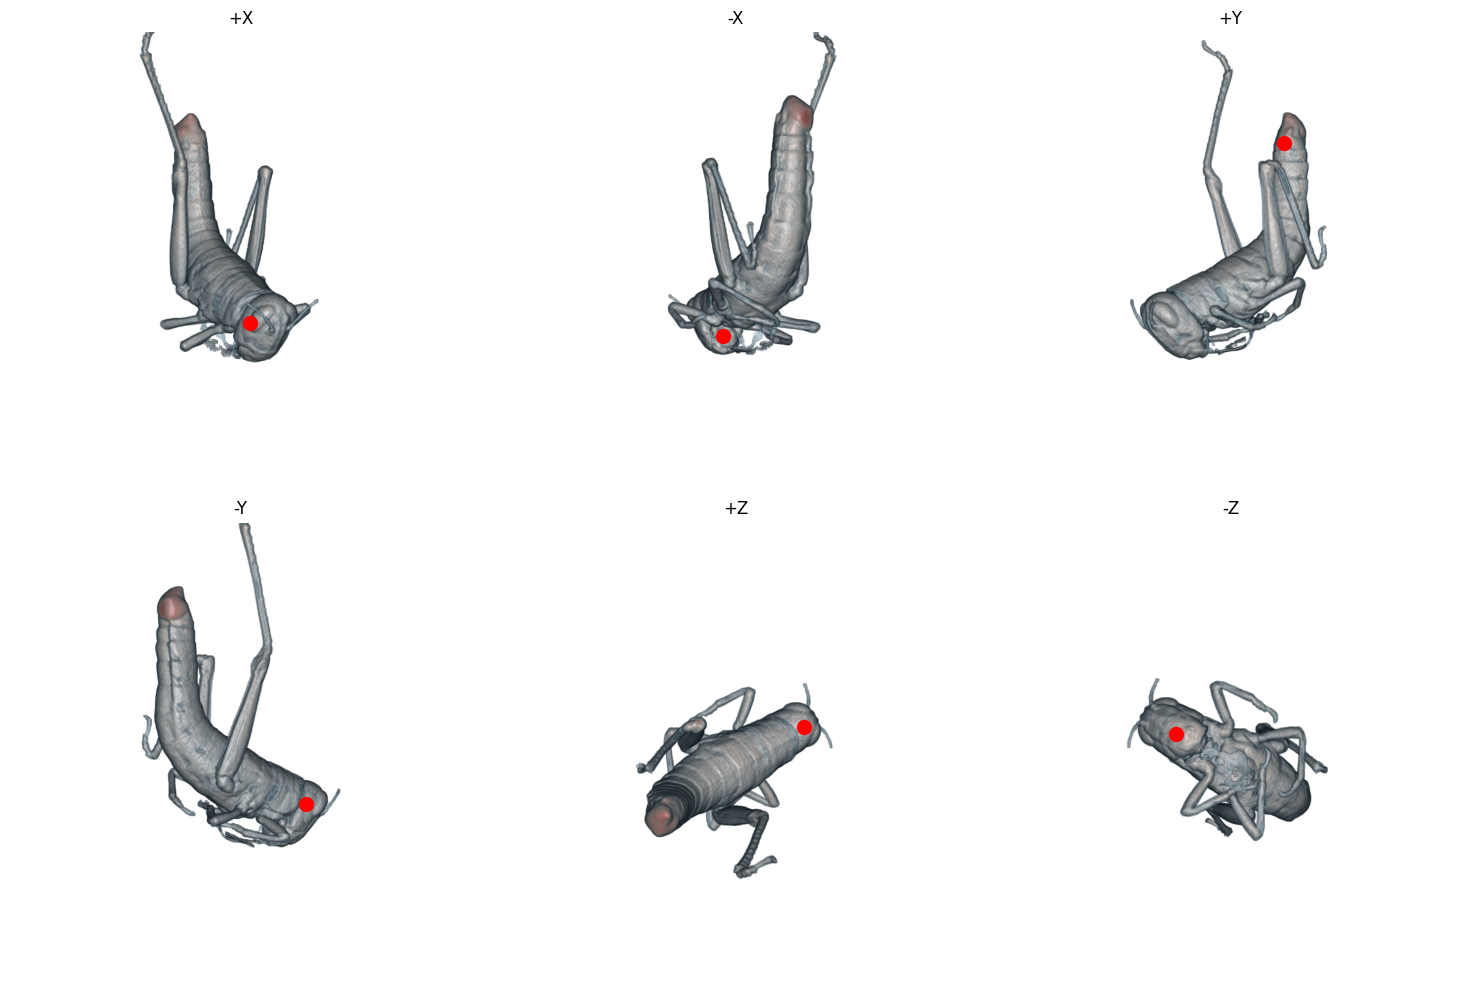

In [32]:
plot_xy_angles(xy_angles)

## Other functions

In [33]:
def get_head_3d(xy_angles, bounds, image_size=(980, 980)):
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    W, H = image_size

    xs, ys, zs = [], [], []
    coords_by_view = {}

    for view, info in xy_angles.items():
        u, v = info["x"], info["y"]

        if view in ["+Z", "-Z"]:
            x = xmin + (u / W) * (xmax - xmin)
            y = ymin + (v / H) * (ymax - ymin)
            coords_by_view[view] = {"x": x, "y": y}
            xs.append(x)
            ys.append(y)

        elif view in ["+Y", "-Y"]:
            x = xmin + (u / W) * (xmax - xmin)
            z = zmin + (v / H) * (zmax - zmin)
            coords_by_view[view] = {"x": x, "z": z}
            xs.append(x)
            zs.append(z)

        elif view in ["+X", "-X"]:
            y = ymin + (u / W) * (ymax - ymin)
            z = zmin + (v / H) * (zmax - zmin)
            coords_by_view[view] = {"y": y, "z": z}
            ys.append(y)
            zs.append(z)

    head_3d = (np.mean(xs), np.mean(ys), np.mean(zs))
    return head_3d, coords_by_view

In [34]:
def extract_dinov2_image_features(
    image_paths,
    model_name="facebook/dinov2-base",
    image_size=448,
    device=None,
):
    """
    Extract one DINOv2 feature vector per image by mean-pooling patch tokens.
    """
    (processor, model), device = _get_dinov2_model(model_name=model_name, device=device)

    features = []
    valid_paths = []

    for image_path in image_paths:
        image_path = Path(image_path)

        image = Image.open(image_path).convert("RGB")
        image = image.resize((image_size, image_size), Image.Resampling.BICUBIC)

        with torch.no_grad():
            inputs = processor(
                images=image,
                return_tensors="pt",
                do_resize=False,
                do_center_crop=False,
            ).to(device)

            outputs = model(**inputs)

        patch_tokens = outputs.last_hidden_state[:, 1:, :]
        image_feat = patch_tokens.mean(dim=1).squeeze(0).cpu().numpy()

        features.append(image_feat)
        valid_paths.append(image_path)

    return valid_paths, np.stack(features, axis=0)
# ---------------------------------------------------------
# 3) Extract DINOv2 features for a list of images
# ---------------------------------------------------------

In [35]:
def plot_images_in_dinov2_pca_space(
    image_paths,
    save_path,
    model_name="facebook/dinov2-base",
    image_size=448,
    thumbnail_size=80,
    figsize=(10, 8),
    device=None,
):
    """
    Run PCA on DINOv2 image features and save a 2D PCA plot with image thumbnails.
    """
    valid_paths, features = extract_dinov2_image_features(
        image_paths=image_paths,
        model_name=model_name,
        image_size=image_size,
        device=device,
    )

    if len(valid_paths) < 2:
        raise ValueError("Need at least 2 images for PCA.")

    pca = PCA(n_components=2)
    coords = pca.fit_transform(features)

    xs = coords[:, 0]
    ys = coords[:, 1]

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(xs, ys, alpha=0)

    for path, x, y in zip(valid_paths, xs, ys):
        img = Image.open(path).convert("RGB")
        img.thumbnail((thumbnail_size, thumbnail_size), Image.Resampling.LANCZOS)
        img_arr = np.asarray(img)

        h, w = img_arr.shape[:2]
        ax.imshow(
            img_arr,
            extent=(x - w / 2, x + w / 2, y - h / 2, y + h / 2),
        )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("DINOv2 PCA of segmented +X_right images")

    x_pad = (xs.max() - xs.min()) * 0.15 + 1
    y_pad = (ys.max() - ys.min()) * 0.15 + 1
    ax.set_xlim(xs.min() - x_pad, xs.max() + x_pad)
    ax.set_ylim(ys.min() - y_pad, ys.max() + y_pad)

    plt.tight_layout()

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

    print("Saved PCA plot to:", save_path)
    print("Explained variance ratio:", pca.explained_variance_ratio_)

    return valid_paths, features, coords, pca
# ---------------------------------------------------------
# 4) PCA plot with image thumbnails
# ---------------------------------------------------------

In [36]:
def run_sfaar_right_pca_pipeline(
    tif_dir="BC",
    tif_prefix="sfaar_1_00",
    tif_indices=(0, 1, 2, 3),
    out_dir="data/new_photos",
    model_name="facebook/dinov2-base",
    image_size=448,
    device=None,
):
    out_dir = Path(out_dir)

    raw_dir = out_dir / "raw_views"
    seg_dir = out_dir / "segmented"
    pca_dir = out_dir / "pca"

    raw_dir.mkdir(parents=True, exist_ok=True)
    seg_dir.mkdir(parents=True, exist_ok=True)
    pca_dir.mkdir(parents=True, exist_ok=True)

    segmented_right_images = []

    for idx in tif_indices:
        tif_path = Path(tif_dir) / f"{tif_prefix}{idx}.tif"
        base = f"sfaar_1_00{idx}"

        print(f"Processing volume: {tif_path}")

        # -------------------------------------------------
        # 1) Save raw views → raw_views/
        # -------------------------------------------------
        saved_views = save_volume_views(
            file_name=tif_path,
            out_dir=raw_dir,
            base=base,
        )

        # -------------------------------------------------
        # 2) Segment → segmented/
        # -------------------------------------------------
        for img_path in saved_views:
            seg_path = seg_dir / f"{img_path.stem}_largest_blob.png"

            save_largest_blob_segment(img_path, seg_path)

            # Only keep +X_right for PCA
            if "+X_right" in img_path.name:
                segmented_right_images.append(seg_path)

    if len(segmented_right_images) == 0:
        raise ValueError("No segmented +X_right images found.")

    print("\nUsing these images for PCA:")
    for p in segmented_right_images:
        print(" ", p)

    # -------------------------------------------------
    # 3) PCA → pca/
    # -------------------------------------------------
    pca_plot_path = pca_dir / "sfaar_right_segmented_dinov2_pca.png"

    plot_images_in_dinov2_pca_space(
        image_paths=segmented_right_images,
        save_path=pca_plot_path,
        model_name=model_name,
        image_size=image_size,
        device=device,
    )

    print("\nSaved PCA plot:", pca_plot_path)

    return segmented_right_images, pca_plot_path

# ---------------------------------------------------------
# 5) Full pipeline for sfaar_1_000, 001, 002, 003
#    - save screenshots
#    - segment all screenshots
#    - keep only segmented +X_right
#    - run PCA on those 4 images
# ---------------------------------------------------------

In [37]:
def make_foreground_patch_mask(
    image,
    patch_size,
    bg_threshold=240,
    fg_patch_ratio=0.20,
):
    img_np = np.array(image)
    h, w = img_np.shape[:2]

    grid_h = h // patch_size
    grid_w = w // patch_size

    bg_mask = np.all(img_np > bg_threshold, axis=2)
    fg_mask_pixel = ~bg_mask

    fg_mask_patch = np.zeros((grid_h, grid_w), dtype=bool)

    for i in range(grid_h):
        for j in range(grid_w):
            patch = fg_mask_pixel[
                i * patch_size:(i + 1) * patch_size,
                j * patch_size:(j + 1) * patch_size,
            ]
            fg_mask_patch[i, j] = patch.mean() > fg_patch_ratio

    return fg_mask_patch.reshape(-1), grid_h, grid_w

# ---------------------------------------------------------
# Foreground patch mask from white background
# ---------------------------------------------------------

In [38]:
def extract_dinov2_patch_tokens_with_fg_mask(
    image_path,
    model_name="facebook/dinov2-base",
    img_size=448,
    bg_threshold=240,
    fg_patch_ratio=0.20,
    device=None,
):
    (processor, model), device = _get_dinov2_model(model_name=model_name, device=device)

    image = Image.open(image_path).convert("RGB")
    image = image.resize((img_size, img_size), Image.Resampling.BICUBIC)

    patch_size = model.config.patch_size
    if img_size % patch_size != 0:
        raise ValueError(f"img_size={img_size} must be divisible by patch_size={patch_size}")

    fg_patch_flat, grid_h, grid_w = make_foreground_patch_mask(
        image=image,
        patch_size=patch_size,
        bg_threshold=bg_threshold,
        fg_patch_ratio=fg_patch_ratio,
    )

    expected_patches = grid_h * grid_w

    with torch.no_grad():
        inputs = processor(
            images=image,
            return_tensors="pt",
            do_resize=False,
            do_center_crop=False,
        ).to(device)

        outputs = model(**inputs)

    patch_tokens = outputs.last_hidden_state[:, 1:, :].squeeze(0).cpu().numpy()

    if patch_tokens.shape[0] != expected_patches:
        raise ValueError(
            f"Patch count mismatch for {image_path}: got {patch_tokens.shape[0]}, expected {expected_patches}"
        )

    if fg_patch_flat.sum() < 3:
        raise ValueError(
            f"Too few foreground patches in {image_path}. "
            f"Try lowering bg_threshold or fg_patch_ratio."
        )

    return image, patch_tokens, fg_patch_flat, grid_h, grid_w

# ---------------------------------------------------------
# Extract patch tokens + foreground mask
# ---------------------------------------------------------

In [39]:
def save_volume_views(
    file_name,
    out_dir,
    base,
    plotter_size=(14*100, 14*100),
    zoom=1.2,
):
    """
    Save the 6 standard view screenshots for a .tif volume.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    vol = vedo.load(str(file_name))
    plt = vedo.Plotter(size=plotter_size, offscreen=True)

    vol.mode(0)

    xmin, xmax, ymin, ymax, zmin, zmax = vol.bounds()
    c = np.array([(xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2])

    diag = np.sqrt((xmax - xmin) ** 2 + (ymax - ymin) ** 2 + (zmax - zmin) ** 2)
    d = diag * 1.2

    views = [
        ("+X_right",  c + [ d, 0, 0],  [0, 0, 1]),
        ("-X_left",   c + [-d, 0, 0],  [0, 0, 1]),
        ("+Y_front",  c + [0,  d, 0],  [0, 0, 1]),
        ("-Y_back",   c + [0, -d, 0],  [0, 0, 1]),
        ("+Z_top",    c + [0, 0,  d],  [0, 1, 0]),
        ("-Z_bottom", c + [0, 0, -d],  [0, 1, 0]),
    ]

    saved_paths = []

    for k, (name, pos, vup) in enumerate(views, start=1):
        plt.clear()
        plt.show(vol, resetcam=True, zoom=zoom)

        cam = plt.camera
        cam.SetFocalPoint(*c)
        cam.SetPosition(*pos)
        cam.SetViewUp(*vup)

        plt.renderer.ResetCameraClippingRange()

        out_path = out_dir / f"{base}_{k}_{name}.png"
        plt.screenshot(str(out_path))
        saved_paths.append(out_path)

    plt.close()
    return saved_paths
# ---------------------------------------------------------
# 1) Save screenshots for one .tif volume
# ---------------------------------------------------------


In [40]:
def save_largest_blob_segment(
    image_filename,
    output_filename=None,
    threshold=None,
):
    """
    Segment the largest dark blob from a grayscale image and save it with white background.
    """
    image_filename = Path(image_filename)

    if output_filename is None:
        output_filename = image_filename.with_name(f"{image_filename.stem}_largest_blob.png")
    else:
        output_filename = Path(output_filename)

    arr = np.array(Image.open(image_filename).convert("L"))

    if threshold is None:
        threshold = arr.mean() - arr.std()

    mask = arr < threshold
    labels = label(mask)
    regions = regionprops(labels)

    if not regions:
        raise ValueError(f"No blobs found in {image_filename}. Try changing the threshold.")

    largest_region = max(regions, key=lambda r: r.area)
    largest_blob = labels == largest_region.label

    segmented = np.full_like(arr, 255)
    segmented[largest_blob] = arr[largest_blob]

    output_filename.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(segmented).save(output_filename)

    return output_filename

# ---------------------------------------------------------
# 2) Segment largest blob from one image
# ---------------------------------------------------------

## Run

In [41]:
# Running pca plot
# ---------------------------------------------------------
# Run
# ---------------------------------------------------------
if __name__ == "__main__":
    segmented_right_images, pca_plot_path = run_sfaar_right_pca_pipeline(
        tif_dir="GH",
        tif_prefix="gras_1_000",
        tif_indices=(0, 1, 2, 3),
        out_dir="data/new_photos",
    )

    print("\nDone.")
    print("PCA input images:")
    for p in segmented_right_images:
        print(p)
    print("PCA plot:", pca_plot_path)

Processing volume: GH\gras_1_0000.tif
[vedo.loaders:126] ERROR: in load(), cannot load GH\gras_1_0000.tif


AttributeError: 'NoneType' object has no attribute 'mode'

In [42]:
image, patch_tokens, fg_patch_flat, grid_h, grid_w = extract_dinov2_patch_tokens_with_fg_mask(r"data\new_photos\segmented\sfaar_1_000_1_+X_right_largest_blob.png")
patch_tokens

NameError: name '_get_dinov2_model' is not defined

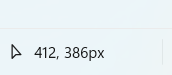

In [43]:
def get_patch_index_from_original_coords(
    x, y,
    orig_w=800, orig_h=600,
    model_size=448,
    patch_size=14
):
    x_rescaled = int(x * model_size / orig_w)
    y_rescaled = int(y * model_size / orig_h)

    grid_w = model_size // patch_size

    patch_i = y_rescaled // patch_size
    patch_j = x_rescaled // patch_size

    patch_index = patch_i * grid_w + patch_j

    return patch_index, (patch_i, patch_j), (x_rescaled, y_rescaled)

In [44]:
patch_index, (patch_i, patch_j), (x_rescaled, y_rescaled) = get_patch_index_from_original_coords(412,386)
head_vec = patch_tokens[patch_index]

NameError: name 'patch_tokens' is not defined

In [45]:
from sklearn.metrics.pairwise import cosine_similarity

sims = cosine_similarity([head_vec], patch_tokens)[0]
K = 10
top_indices = np.argsort(sims)[-K:][::-1]
top_scores = sims[top_indices]
for idx, score in zip(top_indices, top_scores):
    print(f"Patch {idx}: similarity = {score:.3f}")

NameError: name 'head_vec' is not defined

In [46]:
grid_w = 32

for idx in top_indices:
    i = idx // grid_w
    j = idx % grid_w
    print(f"Patch {idx} → (row={i}, col={j})")

NameError: name 'top_indices' is not defined

In [47]:
sim_map = sims.reshape(32, 32)

import matplotlib.pyplot as plt

plt.imshow(sim_map, cmap="jet")
plt.colorbar()
plt.title("Patch similarity map")
plt.axis("off")
plt.show()

ValueError: cannot reshape array of size 4900 into shape (32,32)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def overlay_similarity(image, sims, grid_h=32, grid_w=32, alpha=0.5):
    """
    image: PIL image
    sims: flat similarity array of length grid_h*grid_w, or [grid_h, grid_w]
    """
    if sims.ndim == 1:
        sim_map = sims.reshape(grid_h, grid_w)
    else:
        sim_map = sims

    # normalize to [0, 1] for display
    lo, hi = sim_map.min(), sim_map.max()
    sim_map_norm = (sim_map - lo) / (hi - lo + 1e-8)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.imshow(
        sim_map_norm,
        cmap="jet",
        alpha=alpha,
        interpolation="nearest",
        extent=(0, image.size[0], image.size[1], 0),
    )
    plt.colorbar(label="Cosine similarity")
    plt.axis("off")
    plt.title("Similarity overlay")
    plt.show()

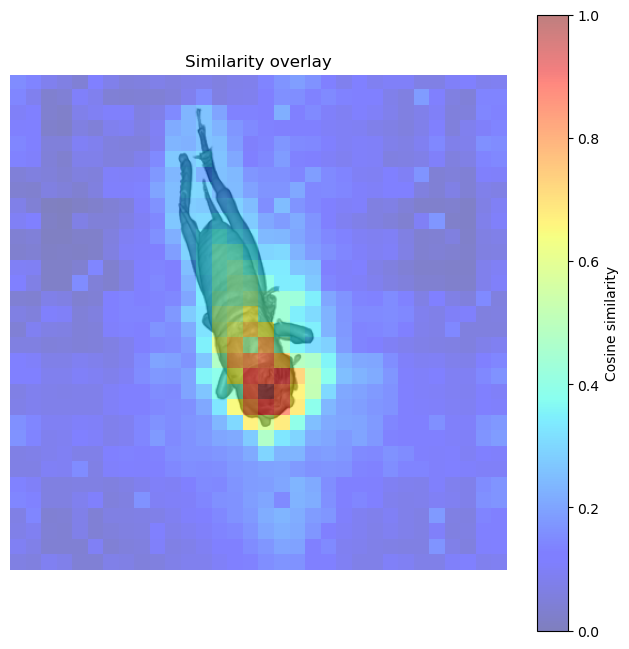

In [ ]:
overlay_similarity(image, sims, grid_h=32, grid_w=32, alpha=0.5)

In [ ]:
image2, patch_tokens2, fg_patch_flat2, grid_h2, grid_w2 = extract_dinov2_patch_tokens_with_fg_mask(r"data\new_photos\segmented\sfaar_1_000_2_-X_left_largest_blob.png")

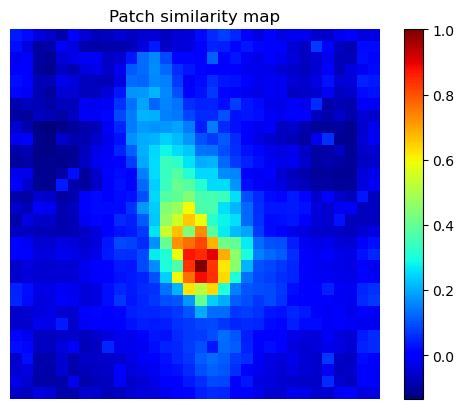

In [ ]:
sims2 = cosine_similarity([head_vec], patch_tokens2)[0]

sim_map2 = sims.reshape(32, 32)

import matplotlib.pyplot as plt

plt.imshow(sim_map2, cmap="jet")
plt.colorbar()
plt.title("Patch similarity map")
plt.axis("off")
plt.show()

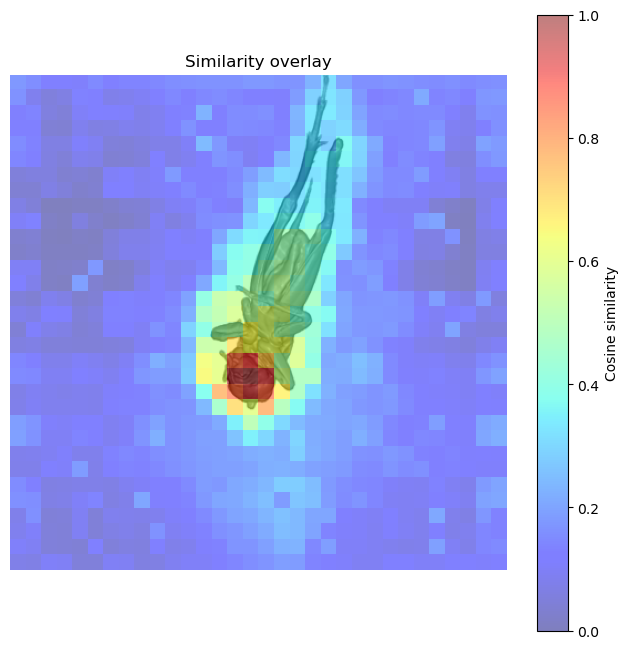

In [ ]:
overlay_similarity(image2, sims2, grid_h=32, grid_w=32, alpha=0.5)

## PCA for visualisation

In [52]:
# ---------------------------------------------------------
# Fit PCA on all segmented images, save only +X_right maps
# ---------------------------------------------------------
def save_xright_pca_maps_from_all_segmented_views(
    segmented_dir="data/new_photos/segmented",
    output_dir="data/new_photos/pca_maps",
    tif_prefix="sfaar_1_00",
    tif_indices=(0, 1, 2, 3),
    view_names=("+X_right", "-X_left", "+Y_front", "-Y_back", "+Z_top", "-Z_bottom"),
    model_name="facebook/dinov2-base",
    img_size=448,
    bg_threshold=240,
    fg_patch_ratio=0.20,
    background_color=(255, 255, 255),
    device=None,
    save_grid=True,
    grid_filename="x_right_pca_from_all_segmented_views_grid.png",
):
    """
    Fit PCA on foreground patch tokens from ALL segmented images across all views,
    but save/plot only the +X_right PCA maps.
    """
    segmented_dir = Path(segmented_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # ---------------------------------
    # Collect all segmented images
    # ---------------------------------
    all_image_paths = []
    xright_image_paths = []

    for idx in tif_indices:
        stem = f"{tif_prefix}{idx}"
        for k, view_name in enumerate(view_names, start=1):
            path = segmented_dir / f"{stem}_{k}_{view_name}_largest_blob.png"
            if not path.exists():
                raise FileNotFoundError(f"Missing segmented image: {path}")

            all_image_paths.append(path)
            if view_name == "+X_right":
                xright_image_paths.append(path)

    if not all_image_paths:
        raise ValueError("No segmented images found.")

    if not xright_image_paths:
        raise ValueError("No +X_right segmented images found.")

    # ---------------------------------
    # Extract tokens/masks for all images
    # ---------------------------------
    image_infos = []
    all_fg_tokens = []

    for image_path in all_image_paths:
        image, patch_tokens, fg_patch_flat, grid_h, grid_w = extract_dinov2_patch_tokens_with_fg_mask(
            image_path=image_path,
            model_name=model_name,
            img_size=img_size,
            bg_threshold=bg_threshold,
            fg_patch_ratio=fg_patch_ratio,
            device=device,
        )

        fg_tokens = patch_tokens[fg_patch_flat]
        all_fg_tokens.append(fg_tokens)

        image_infos.append({
            "path": image_path,
            "image": image,
            "patch_tokens": patch_tokens,
            "fg_patch_flat": fg_patch_flat,
            "grid_h": grid_h,
            "grid_w": grid_w,
            "num_patches": patch_tokens.shape[0],
            "num_fg_patches": int(fg_patch_flat.sum()),
        })

    all_fg_tokens = np.concatenate(all_fg_tokens, axis=0)

    if all_fg_tokens.shape[0] < 3:
        raise ValueError("Too few total foreground patches for PCA.")

    # ---------------------------------
    # Fit PCA on ALL segmented images
    # ---------------------------------
    pca = PCA(n_components=3)
    all_fg_pca = pca.fit_transform(all_fg_tokens)

    for c in range(3):
        ch = all_fg_pca[:, c]
        lo, hi = np.percentile(ch, [1, 99])
        ch = np.clip(ch, lo, hi)
        ch = (ch - lo) / (hi - lo + 1e-8)
        all_fg_pca[:, c] = ch

    # ---------------------------------
    # Split PCA colors back per image
    # ---------------------------------
    pca_rgb_by_path = {}
    start = 0

    for info in image_infos:
        n_fg = info["num_fg_patches"]
        fg_patch_flat = info["fg_patch_flat"]

        fg_rgb = all_fg_pca[start:start + n_fg]
        start += n_fg

        pca_rgb = np.zeros((info["num_patches"], 3), dtype=np.float32)
        pca_rgb[:] = np.array(background_color, dtype=np.float32) / 255.0
        pca_rgb[fg_patch_flat] = fg_rgb
        pca_rgb = pca_rgb.reshape(info["grid_h"], info["grid_w"], 3)

        pca_rgb_by_path[info["path"]] = pca_rgb

    # ---------------------------------
    # Save only +X_right maps
    # ---------------------------------
    saved_paths = []

    for path in xright_image_paths:
        pca_rgb = pca_rgb_by_path[path]
        pca_rgb_big = Image.fromarray(upscale_pca_map(pca_rgb, scale=16))

        out_path = output_dir / f"{path.stem}_dinov2_fg_pca.png"
        pca_rgb_big.save(out_path)
        saved_paths.append(out_path)

    # ---------------------------------
    # Optional grid: only +X_right originals + PCA
    # ---------------------------------
    if save_grid:
        n = len(xright_image_paths)
        fig, axs = plt.subplots(n, 2, figsize=(8, 4 * n))

        if n == 1:
            axs = np.array([axs])

        for i, path in enumerate(xright_image_paths):
            original = Image.open(path).convert("RGB").resize((img_size, img_size), Image.Resampling.BICUBIC)
            pca_img = Image.open(output_dir / f"{path.stem}_dinov2_fg_pca.png")

            axs[i, 0].imshow(original)
            axs[i, 0].set_title(f"{path.name} - segmented")
            axs[i, 0].axis("off")

            axs[i, 1].imshow(pca_img)
            axs[i, 1].set_title(f"{path.name} - PCA from all segmented views")
            axs[i, 1].axis("off")

        plt.tight_layout()
        plt.savefig(output_dir / grid_filename, dpi=200, bbox_inches="tight")
        plt.close()

    print("PCA fitted on all segmented images:", len(all_image_paths))
    print("Saved +X_right PCA maps:", len(saved_paths))
    print("Explained variance ratio:", pca.explained_variance_ratio_)

    return saved_paths

import torch.nn.functional as F

def upscale_pca_map(pca_rgb, scale=16):
    """
    pca_rgb: [H_patch, W_patch, 3] in [0,1]
    scale: integer enlargement factor for crisp block pixels
    """
    tensor = torch.from_numpy(pca_rgb).permute(2, 0, 1).unsqueeze(0).float()  # [1,3,H,W]

    up = F.interpolate(
        tensor,
        scale_factor=scale,
        mode="nearest",
    )

    up = up.squeeze(0).permute(1, 2, 0).numpy()
    return (up * 255).astype(np.uint8)

In [ ]:
save_xright_pca_maps_from_all_segmented_views(
    segmented_dir="data/new_photos/segmented",
    output_dir="data/new_photos/pca_maps",
    tif_prefix="sfaar_1_00",
    tif_indices=(0, 1, 2, 3),
    bg_threshold=240,
    fg_patch_ratio=0.20,
)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

PCA fitted on all segmented images: 24
Saved +X_right PCA maps: 4
Explained variance ratio: [0.1247524  0.0791784  0.06230218]


[WindowsPath('data/new_photos/pca_maps/sfaar_1_000_1_+X_right_largest_blob_dinov2_fg_pca.png'),
 WindowsPath('data/new_photos/pca_maps/sfaar_1_001_1_+X_right_largest_blob_dinov2_fg_pca.png'),
 WindowsPath('data/new_photos/pca_maps/sfaar_1_002_1_+X_right_largest_blob_dinov2_fg_pca.png'),
 WindowsPath('data/new_photos/pca_maps/sfaar_1_003_1_+X_right_largest_blob_dinov2_fg_pca.png')]

## PCA of same picture from six angles

In [ ]:
from pathlib import Path
import numpy as np
import torch
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# DINOv2 cache
# ---------------------------------------------------------
_DINOV2_CACHE = {}


def _get_dinov2_model(model_name="facebook/dinov2-base", device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    key = (model_name, device)
    if key not in _DINOV2_CACHE:
        processor = AutoImageProcessor.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name).to(device)
        model.eval()
        _DINOV2_CACHE[key] = (processor, model)

    return _DINOV2_CACHE[key], device


# ---------------------------------------------------------
# Foreground patch mask from white background
# ---------------------------------------------------------
def make_foreground_patch_mask(
    image,
    patch_size,
    bg_threshold=240,
    fg_patch_ratio=0.20,
):
    img_np = np.array(image)
    h, w = img_np.shape[:2]

    grid_h = h // patch_size
    grid_w = w // patch_size

    bg_mask = np.all(img_np > bg_threshold, axis=2)
    fg_mask_pixel = ~bg_mask

    fg_mask_patch = np.zeros((grid_h, grid_w), dtype=bool)

    for i in range(grid_h):
        for j in range(grid_w):
            patch = fg_mask_pixel[
                i * patch_size:(i + 1) * patch_size,
                j * patch_size:(j + 1) * patch_size,
            ]
            fg_mask_patch[i, j] = patch.mean() > fg_patch_ratio

    return fg_mask_patch.reshape(-1), grid_h, grid_w


# ---------------------------------------------------------
# Extract patch tokens + foreground mask
# ---------------------------------------------------------
def extract_dinov2_patch_tokens_with_fg_mask(
    image_path,
    model_name="facebook/dinov2-base",
    img_size=448,
    bg_threshold=240,
    fg_patch_ratio=0.20,
    device=None,
):
    (processor, model), device = _get_dinov2_model(model_name=model_name, device=device)

    image = Image.open(image_path).convert("RGB")
    image = image.resize((img_size, img_size), Image.Resampling.BICUBIC)

    patch_size = model.config.patch_size
    if img_size % patch_size != 0:
        raise ValueError(f"img_size={img_size} must be divisible by patch_size={patch_size}")

    fg_patch_flat, grid_h, grid_w = make_foreground_patch_mask(
        image=image,
        patch_size=patch_size,
        bg_threshold=bg_threshold,
        fg_patch_ratio=fg_patch_ratio,
    )

    expected_patches = grid_h * grid_w

    with torch.no_grad():
        inputs = processor(
            images=image,
            return_tensors="pt",
            do_resize=False,
            do_center_crop=False,
        ).to(device)

        outputs = model(**inputs)

    patch_tokens = outputs.last_hidden_state[:, 1:, :].squeeze(0).cpu().numpy()

    if patch_tokens.shape[0] != expected_patches:
        raise ValueError(
            f"Patch count mismatch for {image_path}: got {patch_tokens.shape[0]}, expected {expected_patches}"
        )

    if fg_patch_flat.sum() < 3:
        raise ValueError(
            f"Too few foreground patches in {image_path}. "
            f"Try lowering bg_threshold or fg_patch_ratio."
        )

    return image, patch_tokens, fg_patch_flat, grid_h, grid_w


def save_pca_maps_for_six_angles_of_sfaar_1_000(
    segmented_dir="data/new_photos/segmented",
    output_dir="data/new_photos/pca_maps/sfaar_1_000",
    stem="sfaar_1_000",
    view_names=("+X_right", "-X_left", "+Y_front", "-Y_back", "+Z_top", "-Z_bottom"),
    model_name="facebook/dinov2-base",
    img_size=448,
    bg_threshold=240,
    fg_patch_ratio=0.20,
    background_color=(255, 255, 255),
    device=None,
    save_grid=True,
    grid_filename="sfaar_1_000_six_angles_pca_grid.png",
):
    """
    Fit PCA on foreground patch tokens from the six segmented views of sfaar_1_000,
    and save PCA maps for all six angles.
    """
    segmented_dir = Path(segmented_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # ---------------------------------
    # Collect the six segmented images
    # ---------------------------------
    image_paths = []

    for k, view_name in enumerate(view_names, start=1):
        path = segmented_dir / f"{stem}_{k}_{view_name}_largest_blob.png"
        if not path.exists():
            raise FileNotFoundError(f"Missing segmented image: {path}")
        image_paths.append(path)

    # ---------------------------------
    # Extract tokens/masks for all 6 images
    # ---------------------------------
    image_infos = []
    all_fg_tokens = []

    for image_path in image_paths:
        image, patch_tokens, fg_patch_flat, grid_h, grid_w = extract_dinov2_patch_tokens_with_fg_mask(
            image_path=image_path,
            model_name=model_name,
            img_size=img_size,
            bg_threshold=bg_threshold,
            fg_patch_ratio=fg_patch_ratio,
            device=device,
        )

        fg_tokens = patch_tokens[fg_patch_flat]
        all_fg_tokens.append(fg_tokens)

        image_infos.append({
            "path": image_path,
            "image": image,
            "fg_patch_flat": fg_patch_flat,
            "grid_h": grid_h,
            "grid_w": grid_w,
            "num_patches": patch_tokens.shape[0],
            "num_fg_patches": int(fg_patch_flat.sum()),
        })

    all_fg_tokens = np.concatenate(all_fg_tokens, axis=0)

    if all_fg_tokens.shape[0] < 3:
        raise ValueError("Too few total foreground patches for PCA.")

    # ---------------------------------
    # Fit PCA on the 6 views
    # ---------------------------------
    pca = PCA(n_components=3)
    all_fg_pca = pca.fit_transform(all_fg_tokens)

    for c in range(3):
        ch = all_fg_pca[:, c]
        lo, hi = np.percentile(ch, [1, 99])
        ch = np.clip(ch, lo, hi)
        ch = (ch - lo) / (hi - lo + 1e-8)
        all_fg_pca[:, c] = ch

    # ---------------------------------
    # Split PCA colors back per image
    # ---------------------------------
    saved_paths = []
    start = 0

    for info in image_infos:
        n_fg = info["num_fg_patches"]
        fg_patch_flat = info["fg_patch_flat"]

        fg_rgb = all_fg_pca[start:start + n_fg]
        start += n_fg

        pca_rgb = np.zeros((info["num_patches"], 3), dtype=np.float32)
        pca_rgb[:] = np.array(background_color, dtype=np.float32) / 255.0
        pca_rgb[fg_patch_flat] = fg_rgb
        pca_rgb = pca_rgb.reshape(info["grid_h"], info["grid_w"], 3)

        pca_rgb_big = Image.fromarray(upscale_pca_map(pca_rgb, scale=16))

        out_path = output_dir / f"{info['path'].stem}_dinov2_fg_pca.png"
        pca_rgb_big.save(out_path)
        saved_paths.append(out_path)

    # ---------------------------------
    # Optional grid with all 6 originals + PCA
    # ---------------------------------
    if save_grid:
        n = len(image_infos)
        fig, axs = plt.subplots(n, 2, figsize=(8, 4 * n))

        if n == 1:
            axs = np.array([axs])

        for i, (info, pca_path) in enumerate(zip(image_infos, saved_paths)):
            original = Image.open(info["path"]).convert("RGB").resize(
                Image.open(pca_path).size,
                Image.Resampling.NEAREST
            )
            pca_img = Image.open(pca_path)

            axs[i, 0].imshow(original)
            axs[i, 0].set_title(f"{info['path'].name} - segmented")
            axs[i, 0].axis("off")

            axs[i, 1].imshow(pca_img)
            axs[i, 1].set_title(f"{info['path'].name} - PCA")
            axs[i, 1].axis("off")

        plt.tight_layout()
        plt.savefig(output_dir / grid_filename, dpi=200, bbox_inches="tight")
        plt.close()

    print("PCA fitted on segmented views:", len(image_paths))
    print("Saved PCA maps:", len(saved_paths))
    print("Explained variance ratio:", pca.explained_variance_ratio_)

    return saved_paths

import torch.nn.functional as F

def upscale_pca_map(pca_rgb, scale=16):
    """
    pca_rgb: [H_patch, W_patch, 3] in [0,1]
    scale: integer enlargement factor for crisp block pixels
    """
    tensor = torch.from_numpy(pca_rgb).permute(2, 0, 1).unsqueeze(0).float()  # [1,3,H,W]

    up = F.interpolate(
        tensor,
        scale_factor=scale,
        mode="nearest",
    )

    up = up.squeeze(0).permute(1, 2, 0).numpy()
    return (up * 255).astype(np.uint8)

c:\Users\madsl\Miniconda3\Lib\site-packages\transformers\loss\loss_for_object_detection.py:27: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.optimize import linear_sum_assignment


In [ ]:
save_pca_maps_for_six_angles_of_sfaar_1_000()

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

PCA fitted on segmented views: 6
Saved PCA maps: 6
Explained variance ratio: [0.16743441 0.09813362 0.07341306]


[WindowsPath('data/new_photos/pca_maps/sfaar_1_000/sfaar_1_000_1_+X_right_largest_blob_dinov2_fg_pca.png'),
 WindowsPath('data/new_photos/pca_maps/sfaar_1_000/sfaar_1_000_2_-X_left_largest_blob_dinov2_fg_pca.png'),
 WindowsPath('data/new_photos/pca_maps/sfaar_1_000/sfaar_1_000_3_+Y_front_largest_blob_dinov2_fg_pca.png'),
 WindowsPath('data/new_photos/pca_maps/sfaar_1_000/sfaar_1_000_4_-Y_back_largest_blob_dinov2_fg_pca.png'),
 WindowsPath('data/new_photos/pca_maps/sfaar_1_000/sfaar_1_000_5_+Z_top_largest_blob_dinov2_fg_pca.png'),
 WindowsPath('data/new_photos/pca_maps/sfaar_1_000/sfaar_1_000_6_-Z_bottom_largest_blob_dinov2_fg_pca.png')]